In [125]:

#This block prepares the environment for text analysis and topic modelling.
    
# Core
import pandas as pd
import numpy as np
import re

# Dataset
from datasets import load_dataset

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import spacy

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# Topic modelling
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
import umap

import ruptures as rpt


Load Dataset
Steps performed:

Download the dataset
Convert it to a Pandas DataFrame
Display:
number of rows
available columns

The dataset contains research paper metadata including abstracts and categories.

In [64]:
dataset = load_dataset("gfissore/arxiv-abstracts-2021", split="train")

df = pd.DataFrame(dataset)

print("Dataset shape:", df.shape)
print(df.columns)

Dataset shape: (1999486, 11)
Index(['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi',
       'abstract', 'report-no', 'categories', 'versions'],
      dtype='object')


Extract Publication Year
Filter Years

In [65]:
def extract_year(arxiv_id):

    if pd.isna(arxiv_id):
        return None

    arxiv_id = str(arxiv_id)

    if "/" in arxiv_id:
        arxiv_id = arxiv_id.split("/")[-1]

    match = re.match(r"(\d{2})", arxiv_id)

    if match:
        yy = int(match.group(1))
        return 1900 + yy if yy >= 91 else 2000 + yy

    return None


df["year"] = df["id"].apply(extract_year)

df = df[df["year"].between(1990, 2022)]

print(df["year"].describe())

count    1.999486e+06
mean     2.012736e+03
std      7.010062e+00
min      1.991000e+03
25%      2.008000e+03
50%      2.014000e+03
75%      2.019000e+03
max      2.021000e+03
Name: year, dtype: float64


Balanced Sampling

In [66]:
sample_df = (
    df.groupby("year", group_keys=False)
      .apply(lambda x: x.sample(min(len(x), 5000), random_state=42))
)

print("Sample size:", len(sample_df))

Sample size: 148567


In [67]:
sample_df = sample_df.explode("categories")

Select AI Categories
filters only AI-related papers.

In [68]:
ai_categories = ["cs.CL", "cs.AI", "cs.LG"]

ai_df = sample_df[sample_df["categories"].isin(ai_categories)]

ai_df["main_category"] = ai_df["categories"]

print(ai_df["main_category"].value_counts())

main_category
cs.CL    523
cs.AI    390
cs.LG    252
Name: count, dtype: int64


Category Distribution Plot

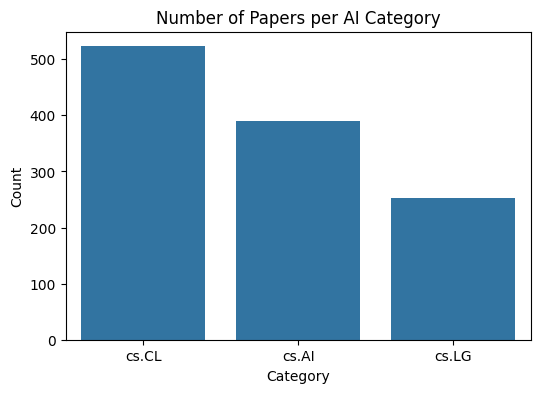

In [69]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=ai_df,
    x="main_category",
    order=ai_df["main_category"].value_counts().index
)

plt.title("Number of Papers per AI Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

AI Research Growth Over Time

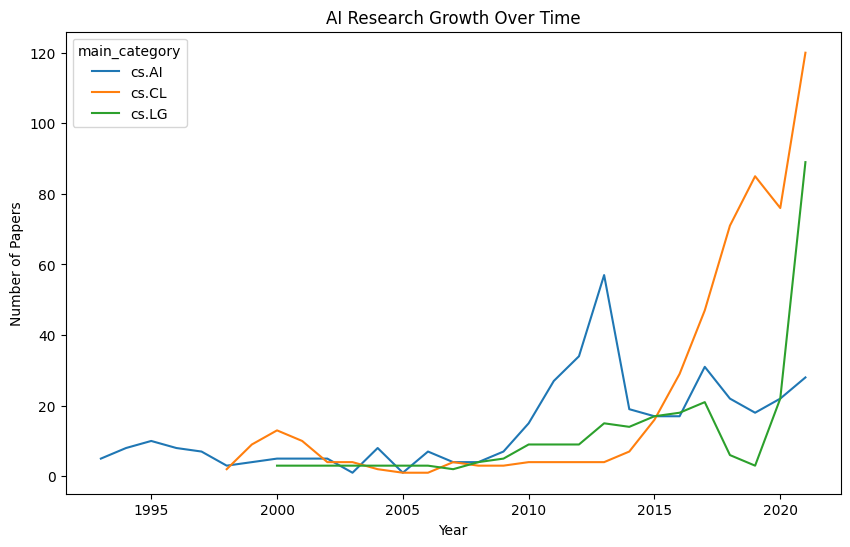

In [70]:
papers_year = (
    ai_df.groupby(["year","main_category"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=papers_year,
    x="year",
    y="count",
    hue="main_category"
)

plt.title("AI Research Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Papers")

plt.show()

Neural Network vs Deep Learning Mentions

In [71]:
ai_df["abstract_lower"] = ai_df["abstract"].str.lower()

ai_df["neural_network"] = ai_df["abstract_lower"].str.contains(
    "neural network", na=False
)

ai_df["deep_learning"] = ai_df["abstract_lower"].str.contains(
    "deep learning", na=False
)

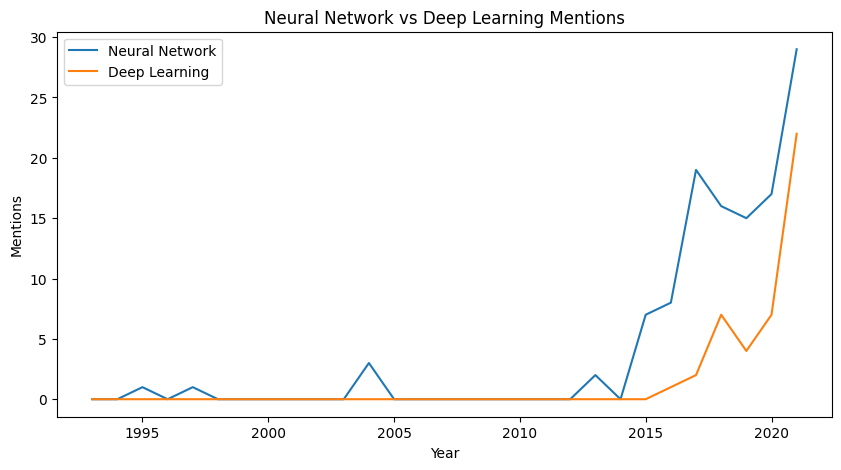

In [72]:
nn_trend = ai_df.groupby("year")["neural_network"].sum()
dl_trend = ai_df.groupby("year")["deep_learning"].sum()

plt.figure(figsize=(10,5))

plt.plot(nn_trend, label="Neural Network")
plt.plot(dl_trend, label="Deep Learning")

plt.legend()

plt.title("Neural Network vs Deep Learning Mentions")

plt.xlabel("Year")
plt.ylabel("Mentions")

plt.show()

Time Period Creation

In [73]:
bins = [1993,1997,2002,2007,2012,2017,2021]

labels = [
    "1993-97",
    "1998-02",
    "2003-07",
    "2008-12",
    "2013-17",
    "2018-21"
]

ai_df["time_period"] = pd.cut(ai_df["year"], bins=bins, labels=labels)

print(ai_df["time_period"].value_counts())

time_period
2018-21    562
2013-17    329
2008-12    141
1998-02     54
2003-07     41
1993-97     33
Name: count, dtype: int64


Text Preprocessing-
lowercase text
remove stopwords
remove punctuation
lemmatize words

In [74]:
nlp = spacy.load("en_core_web_sm")

In [75]:
def preprocess(text):

    doc = nlp(str(text).lower())

    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and token.is_alpha
    ]

    return " ".join(tokens)

In [76]:
ai_df["clean_text"] = ai_df["abstract"].apply(preprocess)

TF-IDF Vectorization

In [77]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(ai_df["clean_text"])

print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (1165, 5000)


PCA Visualization

In [78]:
pca = PCA(n_components=2)

X_reduced = pca.fit_transform(X.toarray())

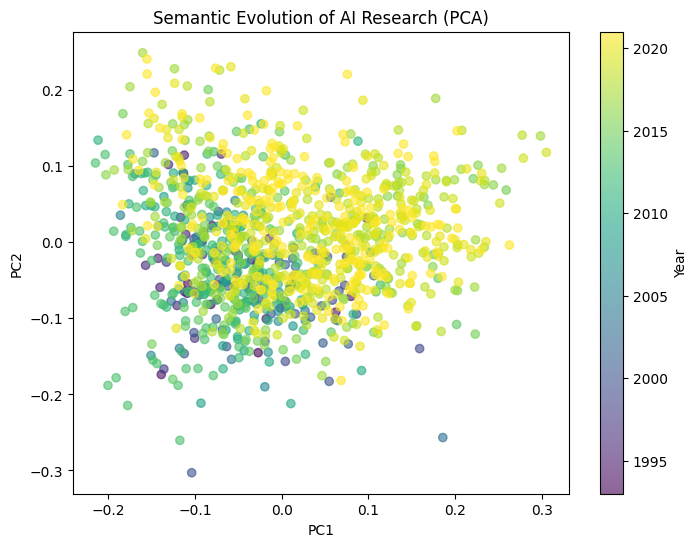

In [79]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_reduced[:,0],
    X_reduced[:,1],
    c=ai_df["year"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Year")

plt.title("Semantic Evolution of AI Research (PCA)")

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

Sentence Embeddings

In [80]:
docs = ai_df["clean_text"].tolist()
years = ai_df["year"].tolist()

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    docs,
    show_progress_bar=True
)

Batches:   0%|          | 0/37 [00:00<?, ?it/s]

In [81]:
umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine"
)

BERTopic Topic Modelling

In [82]:
topic_model = BERTopic(
    umap_model=umap_model,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs, embeddings)

2026-03-30 20:51:28,544 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-30 20:51:32,292 - BERTopic - Dimensionality - Completed ✓
2026-03-30 20:51:32,294 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-30 20:51:32,361 - BERTopic - Cluster - Completed ✓
2026-03-30 20:51:32,369 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-30 20:51:32,627 - BERTopic - Representation - Completed ✓


In [83]:
topic_model.get_topic_info().head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,419,-1_model_language_system_task,"[model, language, system, task, paper, propose...",[present framework generate natural language d...
1,0,78,0_algorithm_datum_learning_method,"[algorithm, datum, learning, method, classific...",[multiclass learning problem involve find defi...
2,1,64,1_agent_policy_game_rl,"[agent, policy, game, rl, reinforcement, learn...",[paper present new methodology employ tester a...
3,2,59,2_probability_theory_logic_uncertainty,"[probability, theory, logic, uncertainty, prob...",[model counting problem compute number model s...
4,3,51,3_constraint_problem_search_solution,"[constraint, problem, search, solution, algori...",[solve combinatorial problem propositional sat...
5,4,46,4_network_neural_learning_graph,"[network, neural, learning, graph, deep, gradi...",[recent year stochastic gradient descent sgd b...
6,5,42,5_dialogue_response_conversation_generation,"[dialogue, response, conversation, generation,...",[underlying difference linguistic pattern gene...
7,6,41,6_word_embedding_sense_representation,"[word, embedding, sense, representation, seman...",[natural language understanding see increase n...
8,7,40,7_speech_asr_acoustic_recognition,"[speech, asr, acoustic, recognition, sequence,...",[paper propose novel datum augmentation method...
9,8,40,8_translation_machine_nmt_neural,"[translation, machine, nmt, neural, english, s...",[paper present attempt build multilingual neur...


Topics Over Time

In [84]:
topics_over_time = topic_model.topics_over_time(
    docs,
    years,
    topics,
    nr_bins=10
)

topic_model.visualize_topics_over_time(topics_over_time)

10it [00:00, 14.44it/s]


In [85]:
topic_model.visualize_topics()

In [86]:
topic_model.visualize_hierarchy()

In [88]:
topic_model.get_topic_info().head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,419,-1_model_language_system_task,"[model, language, system, task, paper, propose...",[present framework generate natural language d...
1,0,78,0_algorithm_datum_learning_method,"[algorithm, datum, learning, method, classific...",[multiclass learning problem involve find defi...
2,1,64,1_agent_policy_game_rl,"[agent, policy, game, rl, reinforcement, learn...",[paper present new methodology employ tester a...
3,2,59,2_probability_theory_logic_uncertainty,"[probability, theory, logic, uncertainty, prob...",[model counting problem compute number model s...
4,3,51,3_constraint_problem_search_solution,"[constraint, problem, search, solution, algori...",[solve combinatorial problem propositional sat...
5,4,46,4_network_neural_learning_graph,"[network, neural, learning, graph, deep, gradi...",[recent year stochastic gradient descent sgd b...
6,5,42,5_dialogue_response_conversation_generation,"[dialogue, response, conversation, generation,...",[underlying difference linguistic pattern gene...
7,6,41,6_word_embedding_sense_representation,"[word, embedding, sense, representation, seman...",[natural language understanding see increase n...
8,7,40,7_speech_asr_acoustic_recognition,"[speech, asr, acoustic, recognition, sequence,...",[paper propose novel datum augmentation method...
9,8,40,8_translation_machine_nmt_neural,"[translation, machine, nmt, neural, english, s...",[paper present attempt build multilingual neur...


In [89]:
topic_model.get_topic(0)

[('algorithm', 0.03300646450401286),
 ('datum', 0.03232474781155917),
 ('learning', 0.027902683641956992),
 ('method', 0.02739717545406797),
 ('classification', 0.025483991621479216),
 ('problem', 0.02450288671055948),
 ('learn', 0.023728061801041315),
 ('metric', 0.02284688611982655),
 ('classifier', 0.022519240477677435),
 ('kernel', 0.020648680205822716)]

Semantic Change Detection

In [90]:
embedding_df = pd.DataFrame(embeddings)

embedding_df["year"] = years

year_embeddings = embedding_df.groupby("year").mean()

year_vectors = year_embeddings.values
years_sorted = year_embeddings.index.tolist()

model = rpt.Pelt(model="rbf").fit(year_vectors)

breakpoints = model.predict(pen=5)

shift_years = [years_sorted[i-1] for i in breakpoints if i-1 < len(years_sorted)]

print("Detected paradigm shifts:", shift_years)

Detected paradigm shifts: [2021]


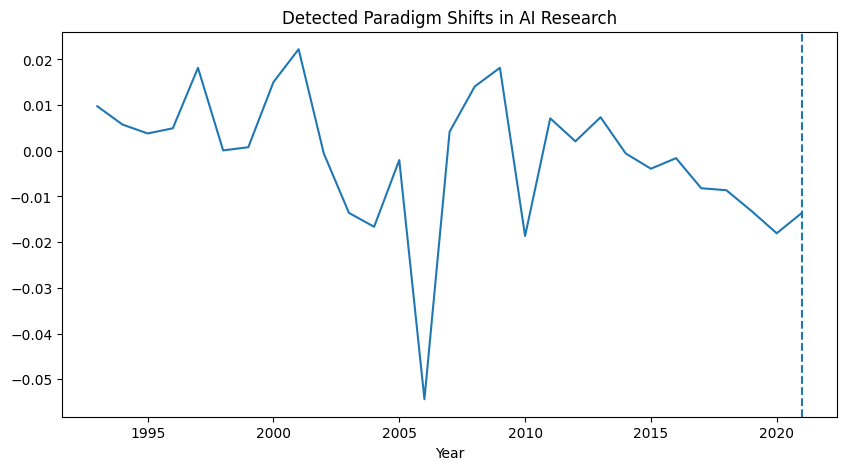

In [91]:
plt.figure(figsize=(10,5))

plt.plot(years_sorted, year_vectors[:,0])

for yr in shift_years:
    plt.axvline(yr, linestyle="--")

plt.title("Detected Paradigm Shifts in AI Research")

plt.xlabel("Year")

plt.show()

Transformer Terminology Analysis

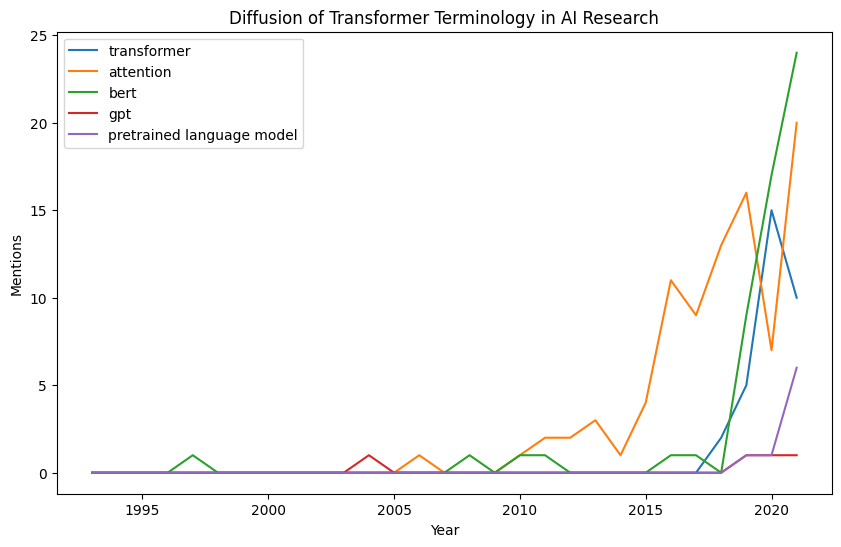

In [92]:
transformer_terms = [
    "transformer",
    "attention",
    "bert",
    "gpt",
    "pretrained language model"
]

ai_df["abstract_lower"] = ai_df["abstract"].str.lower()

for term in transformer_terms:
    ai_df[term] = ai_df["abstract_lower"].str.contains(term, na=False)

transformer_trend = ai_df.groupby("year")[transformer_terms].sum()

plt.figure(figsize=(10,6))

for term in transformer_terms:
    plt.plot(transformer_trend.index, transformer_trend[term], label=term)

plt.legend()
plt.title("Diffusion of Transformer Terminology in AI Research")
plt.xlabel("Year")
plt.ylabel("Mentions")

plt.show()

Semantic Drift

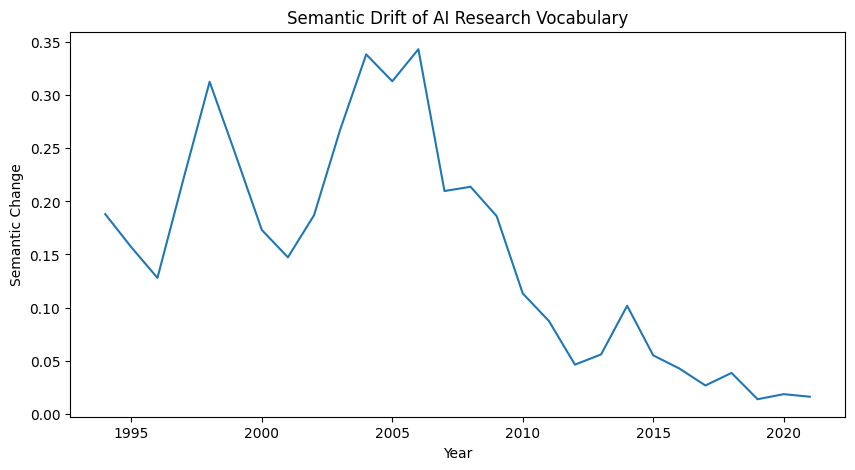

In [93]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

embedding_df = pd.DataFrame(embeddings)
embedding_df["year"] = years

year_embeddings = embedding_df.groupby("year").mean()

years_sorted = year_embeddings.index.tolist()

drift = []

for i in range(1, len(years_sorted)):
    
    prev = year_embeddings.iloc[i-1].values.reshape(1,-1)
    curr = year_embeddings.iloc[i].values.reshape(1,-1)
    
    similarity = cosine_similarity(prev, curr)[0][0]
    
    drift.append(1 - similarity)

plt.figure(figsize=(10,5))

plt.plot(years_sorted[1:], drift)

plt.title("Semantic Drift of AI Research Vocabulary")

plt.xlabel("Year")
plt.ylabel("Semantic Change")

plt.show()

Topic Migration Across Periods

In [94]:
ai_df["topic"] = topics

topic_counts = (
    ai_df.groupby(["time_period","topic"])
    .size()
    .reset_index(name="count")
)

top_topics = topic_counts.sort_values("count", ascending=False).head(10)

print(top_topics)

    time_period  topic  count
115     2018-21     -1    212
92      2013-17     -1    110
69      2008-12     -1     51
93      2013-17      0     36
121     2018-21      5     36
120     2018-21      4     35
95      2013-17      2     35
117     2018-21      1     34
123     2018-21      7     25
125     2018-21      9     24


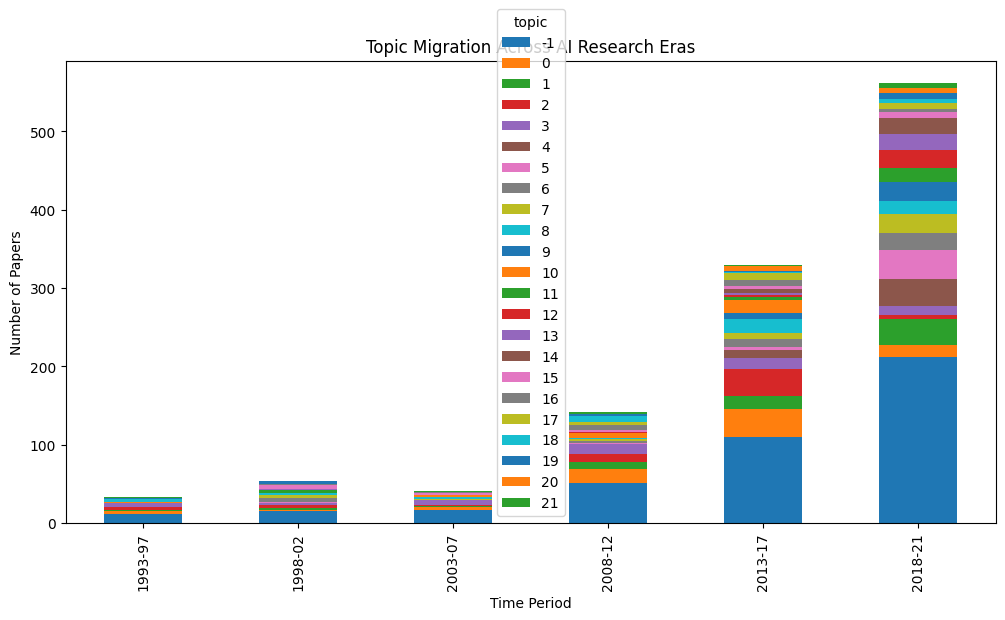

In [95]:
pivot = topic_counts.pivot(
    index="time_period",
    columns="topic",
    values="count"
).fillna(0)

pivot.plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Topic Migration Across AI Research Eras")
plt.xlabel("Time Period")
plt.ylabel("Number of Papers")

plt.show()

In [96]:
for period in ai_df["time_period"].dropna().unique():

    subset = ai_df[ai_df["time_period"] == period]

    vect = TfidfVectorizer(max_features=10)

    X_temp = vect.fit_transform(subset["clean_text"])

    print(period)
    print(vect.get_feature_names_out())
    print()

1993-97
['algorithm' 'datum' 'information' 'learning' 'network' 'paper' 'problem'
 'search' 'set' 'system']

1998-02
['answer' 'language' 'method' 'model' 'paper' 'problem' 'result' 'system'
 'theory' 'word']

2003-07
['algorithm' 'approach' 'base' 'information' 'language' 'model' 'paper'
 'problem' 'result' 'system']

2008-12
['algorithm' 'approach' 'base' 'method' 'model' 'paper' 'present'
 'problem' 'result' 'system']

2013-17
['algorithm' 'approach' 'base' 'datum' 'method' 'model' 'network' 'paper'
 'problem' 'system']

2018-21
['base' 'dataset' 'datum' 'language' 'learning' 'method' 'model' 'propose'
 'result' 'task']



Theory vs Application Shift

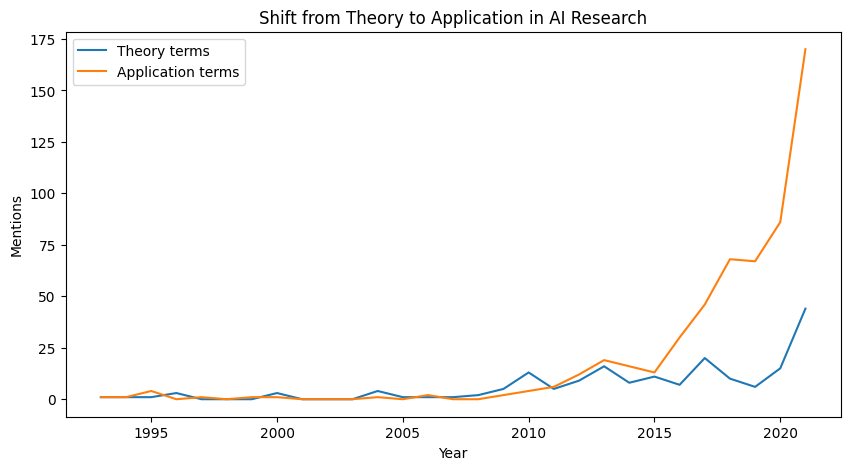

In [97]:
theory_terms = [
    "proof",
    "theorem",
    "convergence",
    "complexity",
    "optimization"
]

application_terms = [
    "dataset",
    "benchmark",
    "evaluation",
    "real-world",
    "deployment"
]

ai_df["abstract_lower"] = ai_df["abstract"].str.lower()

for term in theory_terms:
    ai_df[term] = ai_df["abstract_lower"].str.contains(term, na=False)

for term in application_terms:
    ai_df[term] = ai_df["abstract_lower"].str.contains(term, na=False)

theory_trend = ai_df.groupby("year")[theory_terms].sum().sum(axis=1)
application_trend = ai_df.groupby("year")[application_terms].sum().sum(axis=1)

plt.figure(figsize=(10,5))

plt.plot(theory_trend, label="Theory terms")
plt.plot(application_trend, label="Application terms")

plt.legend()
plt.title("Shift from Theory to Application in AI Research")
plt.xlabel("Year")
plt.ylabel("Mentions")

plt.show()

Dataset / Benchmark Language

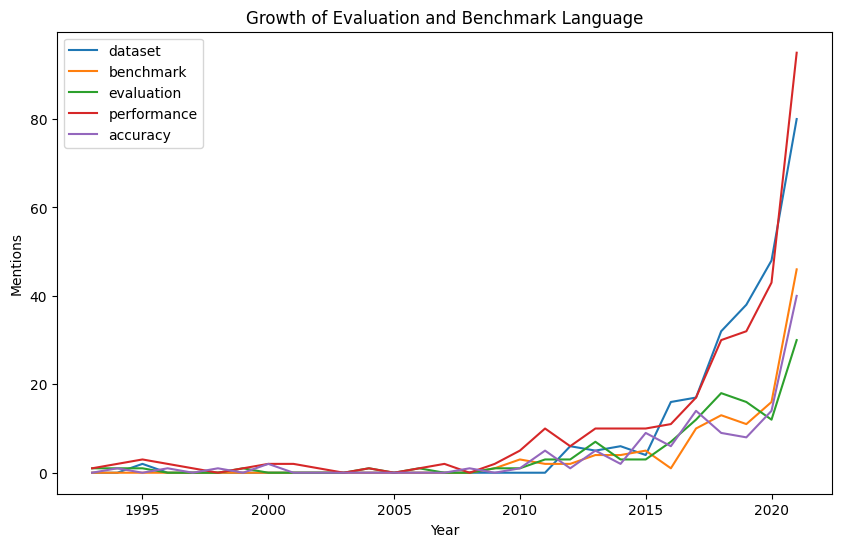

In [98]:
evaluation_terms = [
    "dataset",
    "benchmark",
    "evaluation",
    "performance",
    "accuracy"
]

for term in evaluation_terms:
    ai_df[term] = ai_df["abstract_lower"].str.contains(term, na=False)

evaluation_trend = ai_df.groupby("year")[evaluation_terms].sum()

plt.figure(figsize=(10,6))

for term in evaluation_terms:
    plt.plot(evaluation_trend.index, evaluation_trend[term], label=term)

plt.legend()
plt.title("Growth of Evaluation and Benchmark Language")
plt.xlabel("Year")
plt.ylabel("Mentions")

plt.show()

Large-Scale AI Terminology

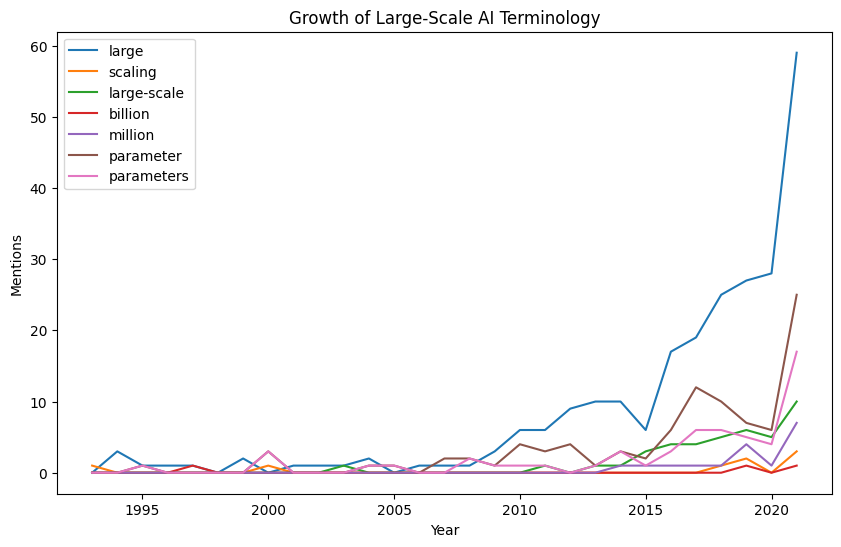

In [99]:
scale_terms = [
    "large",
    "scaling",
    "large-scale",
    "billion",
    "million",
    "parameter",
    "parameters"
]

ai_df["abstract_lower"] = ai_df["abstract"].str.lower()

for term in scale_terms:
    ai_df[term] = ai_df["abstract_lower"].str.contains(term, na=False)

scale_trend = ai_df.groupby("year")[scale_terms].sum()

plt.figure(figsize=(10,6))

for term in scale_terms:
    plt.plot(scale_trend.index, scale_trend[term], label=term)

plt.legend()
plt.title("Growth of Large-Scale AI Terminology")
plt.xlabel("Year")
plt.ylabel("Mentions")

plt.show()

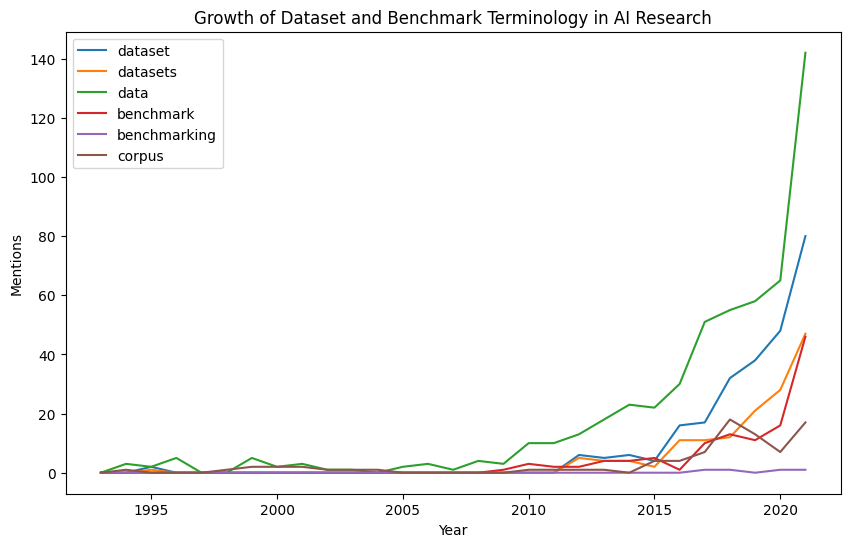

In [100]:
dataset_terms = [
    "dataset",
    "datasets",
    "data",
    "benchmark",
    "benchmarking",
    "corpus"
]

ai_df["abstract_lower"] = ai_df["abstract"].str.lower()

for term in dataset_terms:
    ai_df[term] = ai_df["abstract_lower"].str.contains(term, na=False)

dataset_trend = ai_df.groupby("year")[dataset_terms].sum()

plt.figure(figsize=(10,6))

for term in dataset_terms:
    plt.plot(dataset_trend.index, dataset_trend[term], label=term)

plt.legend()
plt.title("Growth of Dataset and Benchmark Terminology in AI Research")
plt.xlabel("Year")
plt.ylabel("Mentions")

plt.show()

N-Gram Analysis

In [101]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20,
    ngram_range=(1,1)
)

X = vectorizer.fit_transform(ai_df["clean_text"])

words = vectorizer.get_feature_names_out()

counts = X.sum(axis=0).A1

unigram_df = pd.DataFrame({
    "word": words,
    "count": counts
}).sort_values("count", ascending=False)

print(unigram_df)

           word  count
10        model   1625
9        method    817
18         task    724
2          base    699
15      propose    699
4         datum    693
6      language    662
12        paper    632
14      problem    631
16       result    604
1      approach    597
0     algorithm    594
11      network    525
8      learning    516
7         learn    448
17        state    437
19         word    426
5   information    424
3       dataset    407
13  performance    404


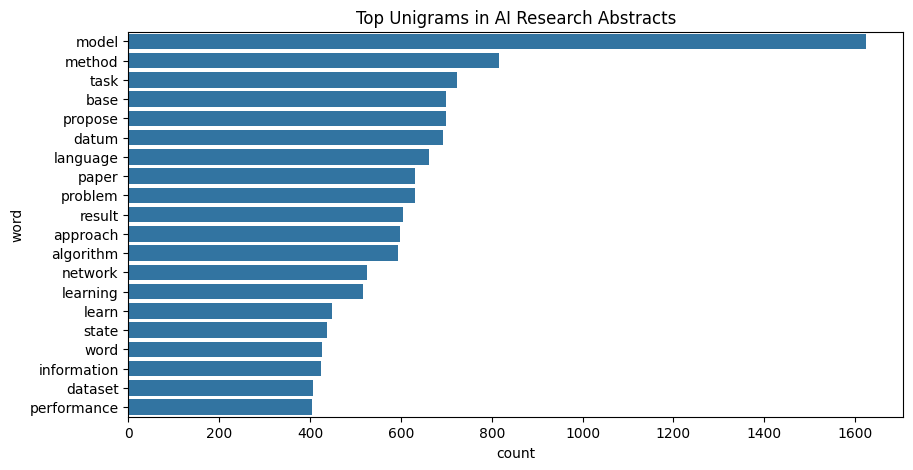

In [102]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=unigram_df,
    x="count",
    y="word"
)

plt.title("Top Unigrams in AI Research Abstracts")

plt.show()

In [103]:
bigram_vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20,
    ngram_range=(2,2)
)

X2 = bigram_vectorizer.fit_transform(ai_df["clean_text"])

bigrams = bigram_vectorizer.get_feature_names_out()

counts = X2.sum(axis=0).A1

bigram_df = pd.DataFrame({
    "bigram": bigrams,
    "count": counts
}).sort_values("count", ascending=False)

print(bigram_df)

                    bigram  count
16               state art    275
8           neural network    187
7         natural language    137
2           language model    113
10           paper propose     98
1      experimental result     89
9            paper present     82
14              real world     79
15  reinforcement learning     78
3      language processing     74
11               pre train     72
5         machine learning     69
12          propose method     69
0            deep learning     61
6      machine translation     59
13           propose novel     58
18          training datum     57
19          word embedding     56
4              large scale     53
17             time series     53


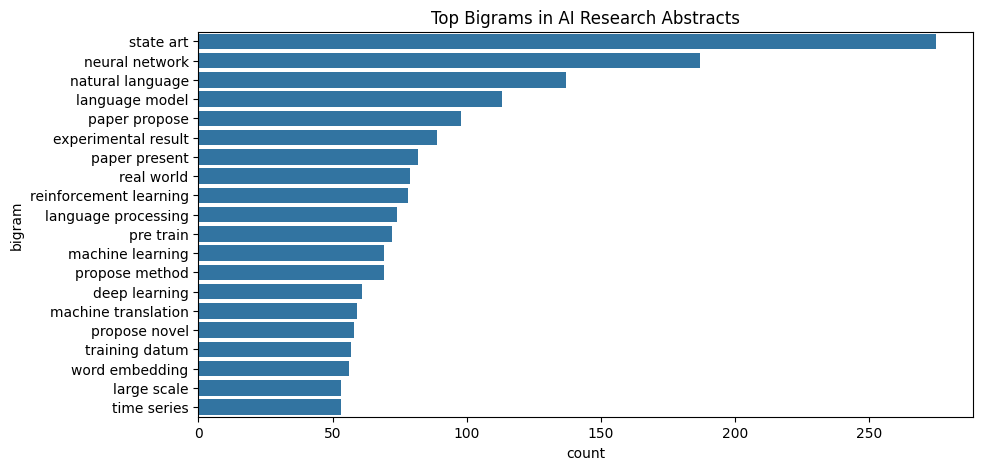

In [104]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=bigram_df,
    x="count",
    y="bigram"
)

plt.title("Top Bigrams in AI Research Abstracts")

plt.show()

In [105]:
from sklearn.feature_extraction.text import CountVectorizer

trigram_vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20,
    ngram_range=(3,3)
)

X3 = trigram_vectorizer.fit_transform(ai_df["clean_text"])

trigrams = trigram_vectorizer.get_feature_names_out()

counts = X3.sum(axis=0).A1

trigram_df = pd.DataFrame({
    "trigram": trigrams,
    "count": counts
}).sort_values("count", ascending=False)

print(trigram_df)

                            trigram  count
8       natural language processing     66
17            state art performance     39
0                 achieve state art     37
18                 state art result     33
16                 state art method     30
11             outperform state art     29
9        neural machine translation     23
12              paper propose novel     23
13               pre train language     21
19             train language model     20
5               deep neural network     20
4      convolutional neural network     20
3                 compare state art     19
14         recurrent neural network     18
15        reinforcement learning rl     18
1         artificial neural network     17
7           markov decision process     16
6   experimental result demonstrate     16
10                    new state art     16
2      automatic speech recognition     15


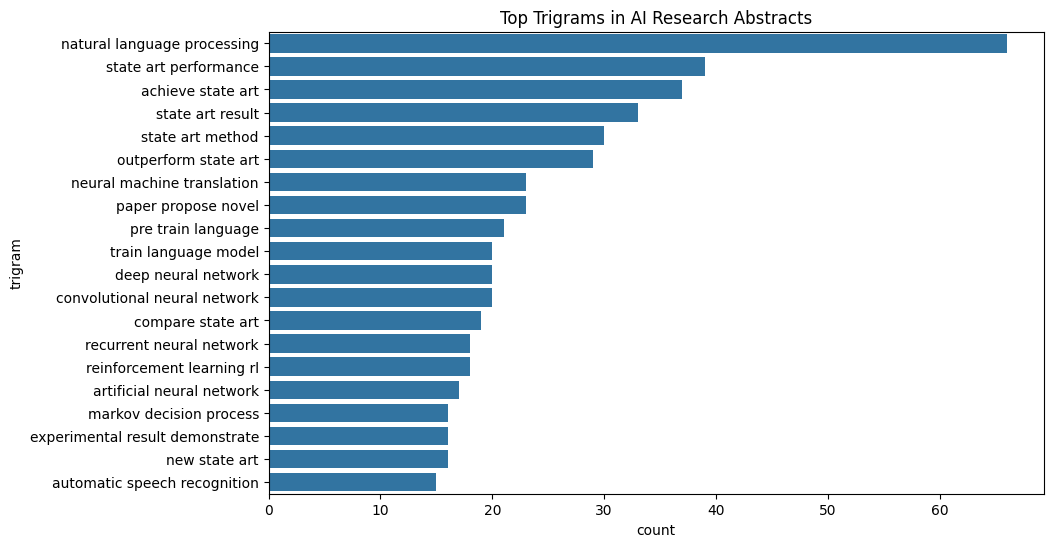

In [106]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=trigram_df,
    x="count",
    y="trigram"
)

plt.title("Top Trigrams in AI Research Abstracts")

plt.show()

Keyword Heatmaps

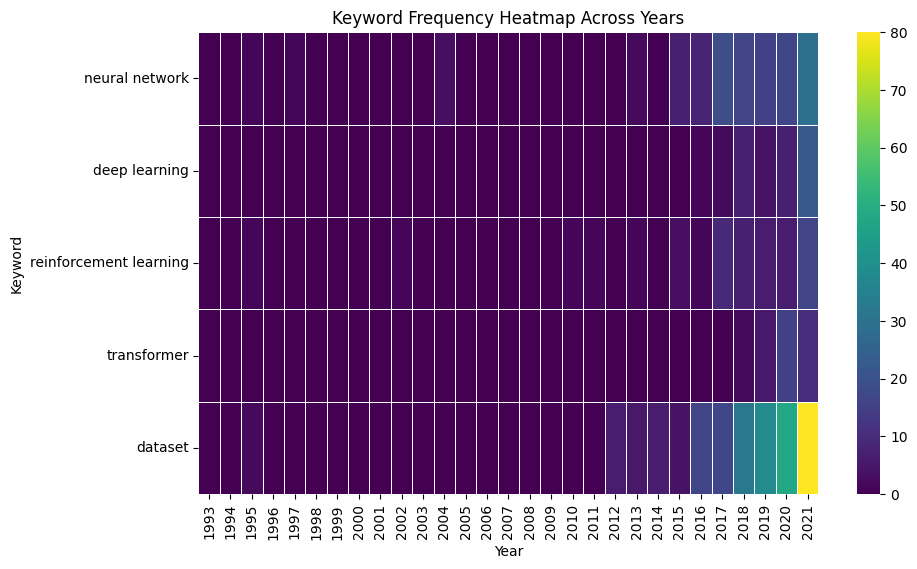

In [107]:
keywords = [
    "neural network",
    "deep learning",
    "reinforcement learning",
    "transformer",
    "dataset"
]

for word in keywords:
    ai_df[word] = ai_df["abstract_lower"].str.contains(word, na=False)

keyword_trend = ai_df.groupby("year")[keywords].sum()

plt.figure(figsize=(10,6))

sns.heatmap(
    keyword_trend.T,
    cmap="viridis",
    linewidths=0.5
)

plt.title("Keyword Frequency Heatmap Across Years")

plt.xlabel("Year")
plt.ylabel("Keyword")

plt.show()

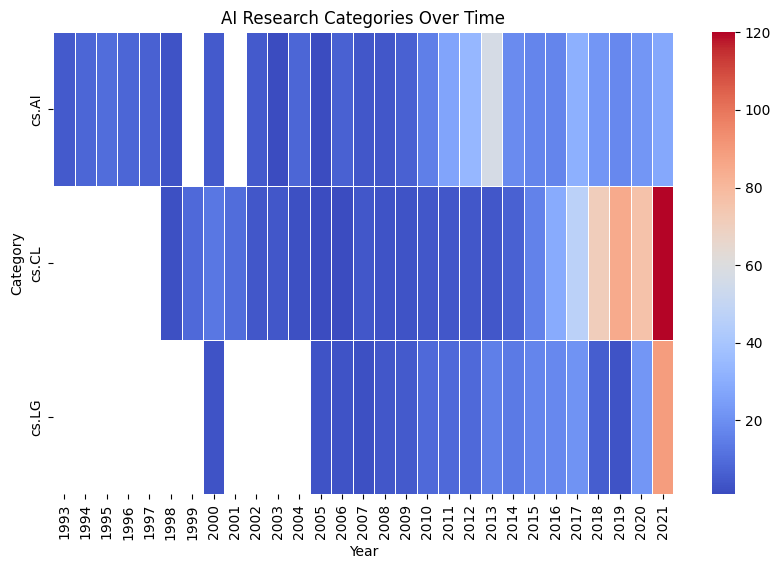

In [108]:
category_trend = ai_df.groupby(["year","main_category"]).size().unstack()

plt.figure(figsize=(10,6))

sns.heatmap(
    category_trend.T,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("AI Research Categories Over Time")

plt.xlabel("Year")
plt.ylabel("Category")

plt.show()

In [109]:
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(text_series, ngram_range=(1,1), top_n=10):
    
    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=ngram_range,
        max_features=100
    )
    
    X = vectorizer.fit_transform(text_series)
    
    counts = X.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()
    
    df = pd.DataFrame({
        "term": terms,
        "count": counts
    }).sort_values("count", ascending=False)
    
    return df.head(top_n)

In [110]:
early_df = ai_df[(ai_df["year"] >= 1993) & (ai_df["year"] <= 2007)]

top_unigrams_early = top_ngrams(early_df["clean_text"], (1,1))
top_bigrams_early = top_ngrams(early_df["clean_text"], (2,2))

print("Top Early Unigrams")
print(top_unigrams_early)

print("\nTop Early Bigrams")
print(top_bigrams_early)

Top Early Unigrams
           term  count
66      problem     90
0     algorithm     81
49        model     80
57        paper     76
6      approach     69
77       result     65
48       method     63
41     language     61
39  information     60
8          base     56

Top Early Bigrams
                       term  count
52           neural network     13
30               high level     12
59            paper present     12
41            logic program     10
14            decision tree     10
50         natural language      8
19            domain theory      8
10  constraint satisfaction      7
47          maximum entropy      7
71              present new      7


In [111]:
modern_df = ai_df[(ai_df["year"] >= 2013) & (ai_df["year"] <= 2021)]

top_unigrams_modern = top_ngrams(modern_df["clean_text"], (1,1))
top_bigrams_modern = top_ngrams(modern_df["clean_text"], (2,2))

print("Top Modern Unigrams")
print(top_unigrams_modern)

print("\nTop Modern Bigrams")
print(top_bigrams_modern)

Top Modern Unigrams
        term  count
51     model   1420
50    method    670
89      task    659
70   propose    607
16     datum    588
44  language    564
10      base    556
62     paper    478
79    result    477
54   network    467

Top Modern Bigrams
                      term  count
89               state art    260
58          neural network    174
55        natural language    124
38          language model    109
64           paper propose     86
27     experimental result     76
78  reinforcement learning     73
65               pre train     72
39     language processing     70
75              real world     66


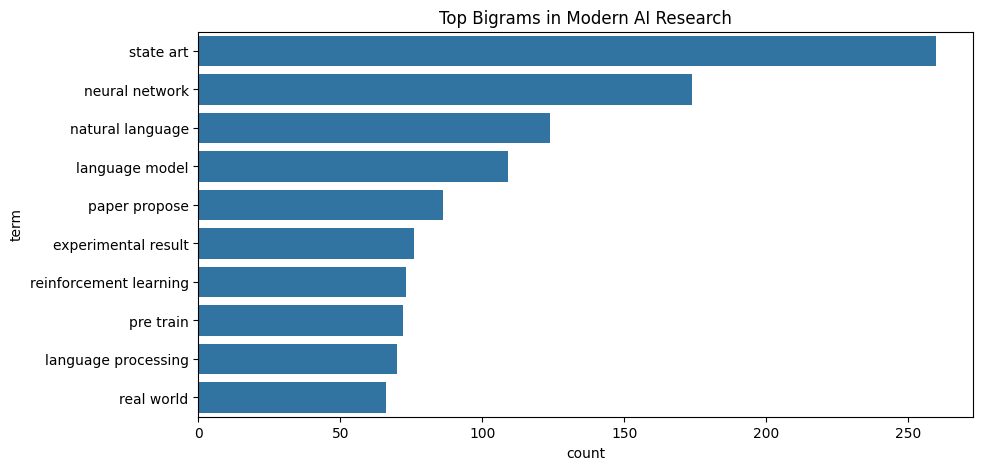

In [112]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_bigrams_modern,
    x="count",
    y="term"
)

plt.title("Top Bigrams in Modern AI Research")

plt.show()

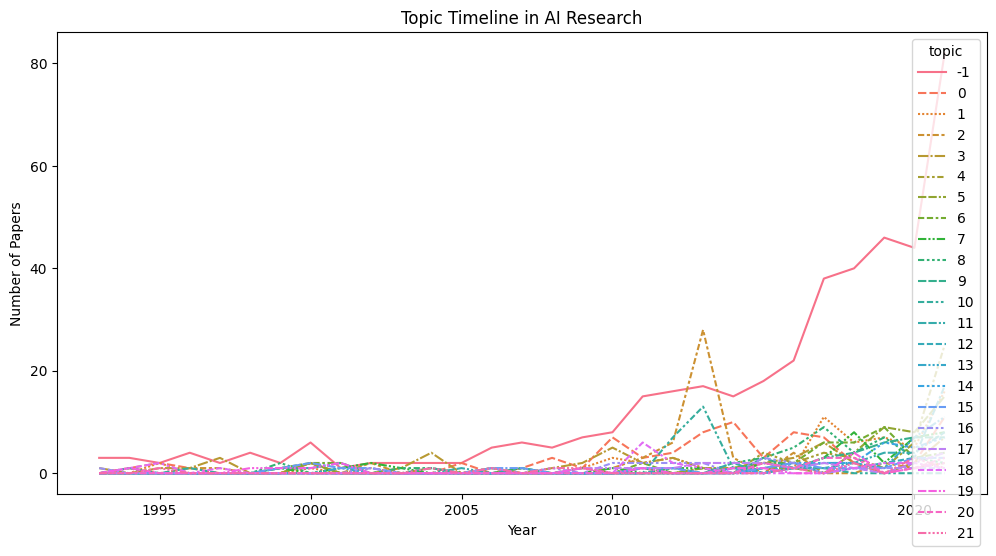

In [113]:
topic_counts = (
    ai_df.groupby(["year","topic"])
    .size()
    .reset_index(name="count")
)

pivot = topic_counts.pivot(
    index="year",
    columns="topic",
    values="count"
).fillna(0)

plt.figure(figsize=(12,6))

sns.lineplot(data=pivot)

plt.title("Topic Timeline in AI Research")
plt.xlabel("Year")
plt.ylabel("Number of Papers")

plt.show()

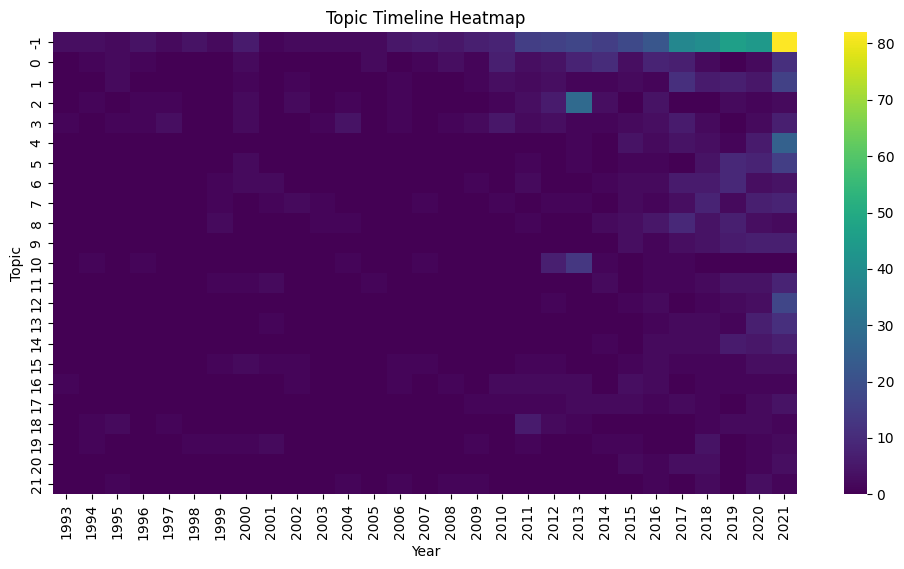

In [114]:
plt.figure(figsize=(12,6))

sns.heatmap(
    pivot.T,
    cmap="viridis"
)

plt.title("Topic Timeline Heatmap")

plt.xlabel("Year")
plt.ylabel("Topic")

plt.show()

Method Diffusion Analysis

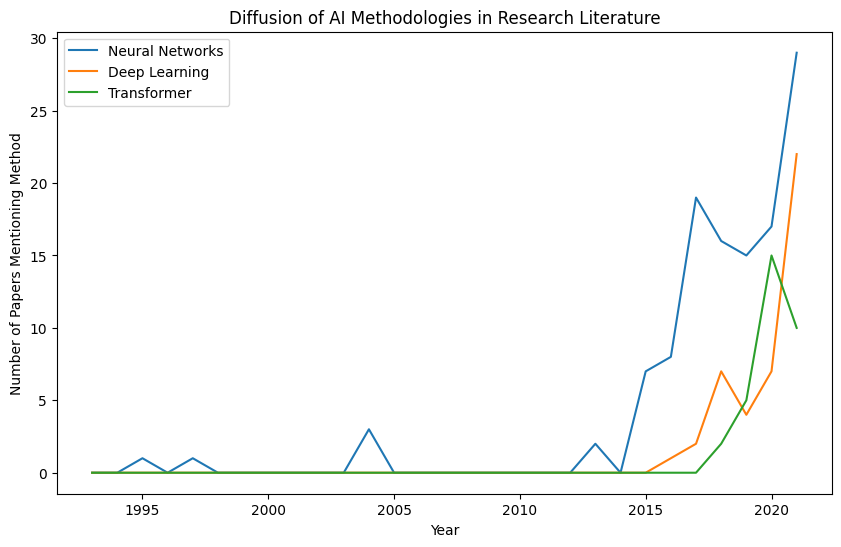

In [115]:
methods = {
    "Neural Networks": "neural network",
    "Deep Learning": "deep learning",
    "Transformer": "transformer"
}

ai_df["abstract_lower"] = ai_df["abstract"].str.lower()

for method, keyword in methods.items():
    ai_df[method] = ai_df["abstract_lower"].str.contains(keyword, na=False)

method_trend = ai_df.groupby("year")[list(methods.keys())].sum()

plt.figure(figsize=(10,6))

for method in methods.keys():
    plt.plot(method_trend.index, method_trend[method], label=method)

plt.legend()

plt.title("Diffusion of AI Methodologies in Research Literature")

plt.xlabel("Year")
plt.ylabel("Number of Papers Mentioning Method")

plt.show()

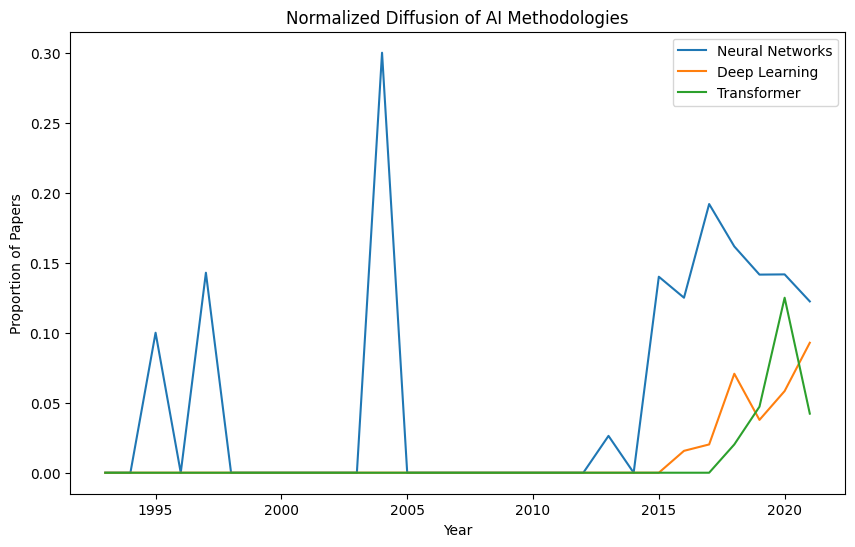

In [116]:
papers_per_year = ai_df.groupby("year").size()

method_norm = method_trend.div(papers_per_year, axis=0)

plt.figure(figsize=(10,6))

for method in methods.keys():
    plt.plot(method_norm.index, method_norm[method], label=method)

plt.legend()

plt.title("Normalized Diffusion of AI Methodologies")

plt.xlabel("Year")
plt.ylabel("Proportion of Papers")

plt.show()

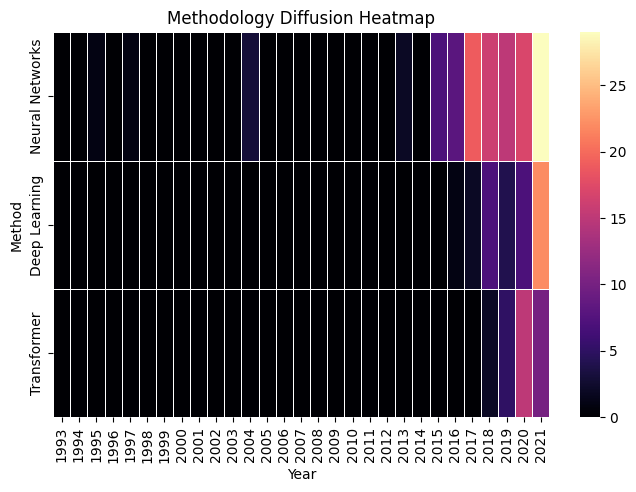

In [117]:
plt.figure(figsize=(8,5))

sns.heatmap(
    method_trend.T,
    cmap="magma",
    linewidths=0.5
)

plt.title("Methodology Diffusion Heatmap")

plt.xlabel("Year")
plt.ylabel("Method")

plt.show()

UMAP Research Landscape

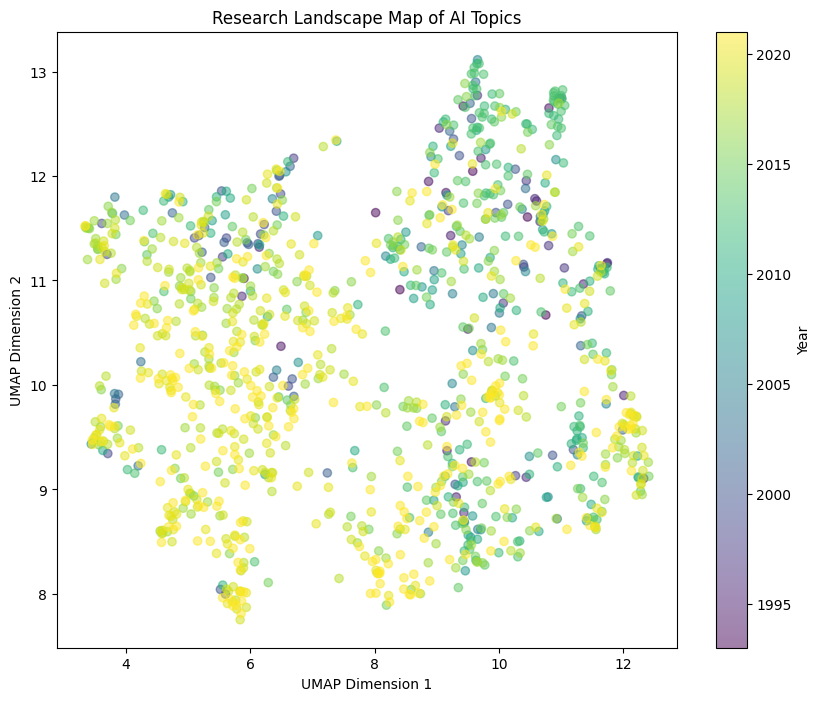

In [118]:
import umap
import matplotlib.pyplot as plt

# Reduce embeddings to 2D
umap_2d = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric="cosine"
)

embedding_2d = umap_2d.fit_transform(embeddings)

plt.figure(figsize=(10,8))

plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=ai_df["year"],
    cmap="viridis",
    alpha=0.5
)

plt.colorbar(label="Year")

plt.title("Research Landscape Map of AI Topics")

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.show()

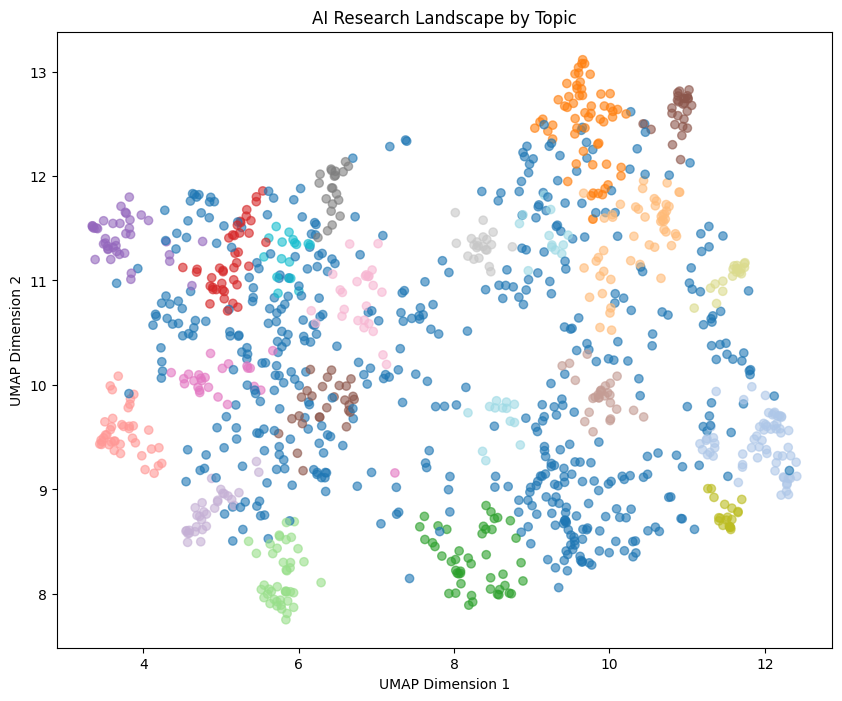

In [119]:
plt.figure(figsize=(10,8))

plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=topics,
    cmap="tab20",
    alpha=0.6
)

plt.title("AI Research Landscape by Topic")

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.show()

In [120]:
topic_info = topic_model.get_topic_info()

print(topic_info.head(10))

   Topic  Count                                         Name  \
0     -1    419                -1_model_language_system_task   
1      0     78            0_algorithm_datum_learning_method   
2      1     64                       1_agent_policy_game_rl   
3      2     59       2_probability_theory_logic_uncertainty   
4      3     51         3_constraint_problem_search_solution   
5      4     46              4_network_neural_learning_graph   
6      5     42  5_dialogue_response_conversation_generation   
7      6     41        6_word_embedding_sense_representation   
8      7     40            7_speech_asr_acoustic_recognition   
9      8     40             8_translation_machine_nmt_neural   

                                      Representation  \
0  [model, language, system, task, paper, propose...   
1  [algorithm, datum, learning, method, classific...   
2  [agent, policy, game, rl, reinforcement, learn...   
3  [probability, theory, logic, uncertainty, prob...   
4  [constraint,

Save clean dataset

In [121]:
# Save cleaned dataset for modelling notebooks

ai_df.to_csv("team38_clean_corpus.csv", index=False)

print("Saved cleaned dataset:", len(ai_df))

Saved cleaned dataset: 1165
